In [51]:
import os
import json
import math
import matplotlib.pyplot as plt
from collections import defaultdict

In [52]:
class Colour:
    BLUE = '\033[94m'
    CYAN = '\033[96m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BOLD = '\033[1m'
    END = '\033[0m'

In [53]:
def clean_number(value):
    if value is None:
        return 0.0
    
    # if already a numer
    if isinstance(value, (int, float)):
        return float(value)
    else:
        clean_str = str(value).strip()
        is_negative = clean_str.endswith('-') or clean_str.startswith('-')
        
        clean_str = clean_str.replace(',', '.') # french comma -> point
        clean_str = ''.join(c for c in clean_str if c.isdigit() or c == '.' or c == '-')
        
        try:
            val = float(clean_str)
            return val if not is_negative else -abs(val)
        except ValueError:
            return 0.0

In [54]:
def analyze_benford(numbers, input_file, save=True):
    # only positive numbers
    nombres_significatifs = [n for n in numbers if n > 0]
    total_obs = len(nombres_significatifs)

    if total_obs < 5:
        print(f"{Colour.YELLOW}⚠️ Pas assez de données chiffrées pour un test de Benford fiable.{Colour.END}")
        return

    premier_chiffre_count = defaultdict(int)
    for n in nombres_significatifs:
        str_n = str(n).replace('.', '').lstrip('0')
        if str_n:
            premier_chiffre_count[int(str_n[0])] += 1
    
    observed_freqs = []
    expected_freqs = []
    digits = range(1, 10)

    print(f"{Colour.CYAN}analyse Loi de Benford{Colour.END}")
    
    suspicious = False
    for d in digits:
        obs = (premier_chiffre_count[d] / total_obs) * 100
        exp = math.log10(1 + 1/d) * 100
        observed_freqs.append(obs)
        expected_freqs.append(exp)
        
        # suspect if high discrepancy and enough data
        if abs(obs - exp) > 15 and total_obs > 20:
            suspicious = True

    if suspicious:
        print(f"{Colour.RED}🚨 ALERTE : La distribution des chiffres semble anormale (possible falsification).{Colour.END}")
    else:
        print(f"{Colour.GREEN}✅ La distribution des chiffres suit une logique naturelle.{Colour.END}")

    # plot
    plt.figure(figsize=(10, 5))
    bar_width = 0.35
    index = range(len(digits))

    plt.bar(index, observed_freqs, bar_width, label='Observé', color='#3498db', edgecolor='#2980b9', linewidth=1.2)
    plt.bar([i + bar_width for i in index], expected_freqs, bar_width, label='Benford (théorique)', color='#e74c3c', alpha=0.8, edgecolor='#c0392b', linewidth=1.2)

    plt.xlabel('Premier chiffre (1-9)', fontsize=12, fontweight='bold')
    plt.ylabel('Fréquence (%)', fontsize=12, fontweight='bold')
    plt.title(f"Analyse Loi de Benford - {os.path.basename(input_file)}", fontsize=14, fontweight='bold')
    plt.xticks([i + bar_width / 2 for i in index], digits, fontsize=11)
    plt.yticks(fontsize=10)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylim(0, max(max(observed_freqs), max(expected_freqs)) + 5)
    
    # Ajouter les valeurs au-dessus des barres
    for i, (obs, exp) in enumerate(zip(observed_freqs, expected_freqs)):
        plt.text(i, obs + 0.5, f'{obs:.1f}', ha='center', va='bottom', fontsize=8, color='#2980b9')
        plt.text(i + bar_width, exp + 0.5, f'{exp:.1f}', ha='center', va='bottom', fontsize=8, color='#c0392b')
    
    plt.tight_layout()
    
    os.makedirs("plots", exist_ok=True)
    clean_name = os.path.basename(input_file).replace('.json', '.png')
    if save:
        plt.savefig(f"plots/benford_{clean_name}", dpi=150, bbox_inches='tight')
        print(f"📊 Graphique Benford sauvegardé dans plots/benford_{clean_name}")
    plt.show()
    plt.close()

In [55]:
def verification_facture(input_file, save=True):
    if not os.path.exists(input_file):
        print(f"{Colour.RED}❌ Fichier introuvable : {input_file}{Colour.END}")
        return

    try:
        with open(input_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"{Colour.RED}❌ JSON invalide.{Colour.END}")
        return

    # basic check
    if "numero_facture" not in data and "emetteur" not in data:
         print(f"{Colour.YELLOW}⚠️ Ce fichier ne ressemble pas à une facture attendue.{Colour.END}")
         return

    print(f"{Colour.BLUE}{Colour.BOLD}" + "="*60)
    print(f" AUDIT DE FACTURE : {data.get('numero_facture', 'Inconnue')}")
    print("="*60 + f"{Colour.END}")

    errors = []
    numbers = [] 
    
    # total HT, TVA, TTC
    montant_ht = clean_number(data.get('montant_ht'))
    montant_tva = clean_number(data.get('montant_tva'))
    montant_ttc = clean_number(data.get('montant_ttc'))
    numbers.extend([montant_ht, montant_tva, montant_ttc])

    # analysis line by line
    articles = data.get('articles', [])
    somme_calculee_ht = 0.0

    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")
    print(f"{Colour.CYAN}vérification ligne par ligne{Colour.END}")

    for i, item in enumerate(articles):
        libelle = item.get('libelle', 'Article inconnu')
        
        # exrtract data
        qte = clean_number(item.get('quantite'))
        poids = clean_number(item.get('poids'))
        pu = clean_number(item.get('prix_unitaire'))
        remise = clean_number(item.get('remise'))
        montant_ligne_annonce = clean_number(item.get('montant'))
        
        numbers.extend([x for x in [qte, poids, pu, remise, montant_ligne_annonce] if x > 0])

        match_found = False
        explication_match = ""

        # hypothesis 1
        calc_qty = (qte * pu) - remise
        # hypothesis 2
        calc_poids = (poids * pu) - remise
        # hypothesis 3
        calc_poids_grammes = ((poids / 1000) * pu) - remise

        marge = 0.05

        if abs(calc_qty - montant_ligne_annonce) <= marge:
            match_found = True
            explication_match = "Validé par Quantité"
        
        elif abs(calc_poids - montant_ligne_annonce) <= marge:
            match_found = True
            explication_match = "Validé par Poids (Unité directe)"

        elif abs(calc_poids_grammes - montant_ligne_annonce) <= marge:
            match_found = True
            explication_match = "Validé par Poids (Conversion g->kg)"

        # results
        if match_found:
            somme_calculee_ht += montant_ligne_annonce
            # print(f"  ✅ Ligne {i+1} OK ({explication_match})")
        else:
            # no hypthesis verified, we have a problem
            errors.append(
                f"Ligne {i+1} ({libelle}) - MONTANT SUSPECT ({montant_ligne_annonce}) :\n"
                f"      -> Via Quantité ({qte} x {pu}) = {calc_qty:.2f}\n"
                f"      -> Via Poids ({poids} x {pu}) = {calc_poids:.2f}\n"
                f"      -> Via Grammes ({poids}/1000 x {pu}) = {calc_poids_grammes:.2f}"
            )
            somme_calculee_ht += montant_ligne_annonce

    if not errors:
        print(f"{Colour.GREEN}✅ Cohérence mathématique des lignes : TOUT EST OK.{Colour.END}")
    else:
        print(f"{Colour.RED}❌ Incohérences détectées dans les lignes :{Colour.END}")
        for e in errors:
            print(f"  ⚠️ {e}")

    # total sum check
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")
    print(f"{Colour.CYAN}vérification Totaux{Colour.END}")
    
    # total vs HT
    if abs(somme_calculee_ht - montant_ht) < 0.1:
        print(f"{Colour.GREEN}✅ Somme des articles ({somme_calculee_ht:.2f}) == Total HT ({montant_ht:.2f}){Colour.END}")
    else:
        print(f"{Colour.RED}❌ Somme des articles ({somme_calculee_ht:.2f}) != Total HT ({montant_ht:.2f}){Colour.END}")

    # HT + TVA = TTC
    calcul_ttc = montant_ht + montant_tva
    if abs(calcul_ttc - montant_ttc) < 0.1:
        print(f"{Colour.GREEN}✅ HT ({montant_ht:.2f}) + TVA ({montant_tva:.2f}) == TTC ({montant_ttc:.2f}){Colour.END}")
    else:
        print(f"{Colour.RED}❌ Erreur de TVA : {montant_ht} + {montant_tva} = {calcul_ttc:.2f} (Document dit: {montant_ttc}){Colour.END}")

    # benford
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")
    analyze_benford(numbers, input_file, save=save)
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")

 AUDIT DE FACTURE : 200934
----------------------------------------------------------------------
vérification ligne par ligne
✅ Cohérence mathématique des lignes : TOUT EST OK.
----------------------------------------------------------------------
vérification Totaux
✅ Somme des articles (414.80) == Total HT (414.80)
✅ HT (414.80) + TVA (82.96) == TTC (497.76)
----------------------------------------------------------------------
analyse Loi de Benford
✅ La distribution des chiffres suit une logique naturelle.
📊 Graphique Benford sauvegardé dans plots/benford_facture1.png


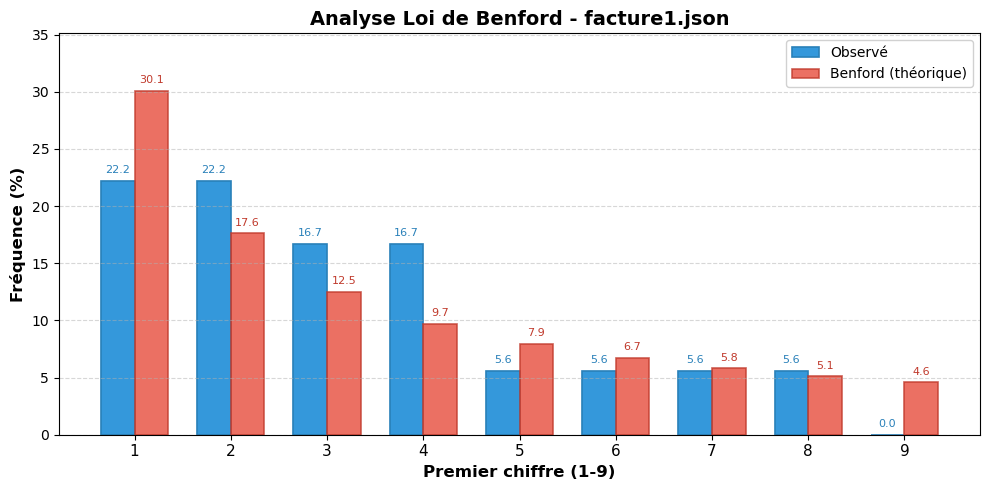

----------------------------------------------------------------------


In [56]:
verification_facture("extracted/facture1.json", save=True)